In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from rouge_score import rouge_scorer
from itertools import combinations
from sklearn.isotonic import IsotonicRegression

from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer
from nltk.stem import PorterStemmer


In [ ]:
OBS = '../02_data/2026-05-28/compendium/qwen/qwen'

In [4]:
scorer = rouge_scorer.RougeScorer(["rouge1", "rouge2", "rougeL"], use_stemmer=True)

def rouge_match(s1: str, s2: str, metric="rougeL") -> dict:
    scores = scorer.score(s1.lower().strip(), s2.lower().strip())
    return scores[metric].fmeasure  # or .precision / .recall

In [5]:
stop = set(stopwords.words('english'))
tokenizer = RegexpTokenizer(r'\w+')
stemmer = PorterStemmer()


def lexical_match(s1, s2, stopword_removal=True, use_stemmer=True):
    s1 = tokenizer.tokenize(s1.lower().strip())
    s2 = tokenizer.tokenize(s2.lower().strip())

    if use_stemmer == True:
        s1 = [stemmer.stem(w) for w in s1]
        s2 = [stemmer.stem(w) for w in s2]

    words1, words2 = set(s1), set(s2)
    if stopword_removal == True:
        words1, words2 = words1 - stop, words2 - stop
        
    if min(len(words1), len(words2)) == 0:
        return 0

    overlap = len(words1 & words2) / min(len(words1), len(words2))
    return overlap

def set_lexical_match(paragraphs):
    texts = [d["text"] for d in paragraphs]
    if len(texts) < 2:
        return np.nan

    pairs = list(combinations(texts, 2))
    scores = [lexical_match(a, b) for a, b in pairs]
    return np.mean(scores)

def extract_texts(doc_list):
    return " ".join(d["text"] for d in doc_list)

def add_lexical_scores(df):
    df = df.copy()
    
    retrieved_text = df["retrieved"].apply(extract_texts)
    reference_text = df["reference"].apply(extract_texts)

    df['lex_retrieved'] = df['retrieved'].apply(set_lexical_match)
    df['lex_reference'] = df['reference'].apply(set_lexical_match)

    df["lex_input_retrieved"]   = [lexical_match(i, r) for i, r in zip(df["input"], retrieved_text)]
    df["lex_retrieved_answer"]  = [lexical_match(r, a) for r, a in zip(retrieved_text, df["generated_answer"])]
    df["lex_input_gen_answer"]  = [lexical_match(i, a) for i, a in zip(df["input"], df["generated_answer"])]

    df["rouge_input_retrieved"]   = [rouge_match(i, r) for i, r in zip(df["input"], retrieved_text)]
    df["rouge_retrieved_answer"]  = [rouge_match(r, a) for r, a in zip(retrieved_text, df["generated_answer"])]
    df["rouge_input_gen_answer"]  = [rouge_match(i, a) for i, a in zip(df["input"], df["generated_answer"])]

    df["lex_input_reference"]   = [lexical_match(i, r) for i, r in zip(df["input"], reference_text)]
    df["lex_reference_answer"]  = [lexical_match(r, a) for r, a in zip(reference_text, df["answer"])]

    return df

In [6]:
results = {}

for id in os.listdir(OBS):
    if id == '.DS_Store':
        continue
    
    info = id.split('_')
    retriever = info[3]

    if retriever == 'oracle' or retriever == 'empty':
        continue

    df = pd.read_json(f"{OBS}/{id}/results.jsonl", orient='records', lines=True)
    df = add_lexical_scores(df)

    results[f"{retriever}"] = df

In [7]:
results['dense']['lex_input_retrieved'].describe()

count    598.000000
mean       0.840977
std        0.178174
min        0.250000
25%        0.714286
50%        0.857143
75%        1.000000
max        1.000000
Name: lex_input_retrieved, dtype: float64

In [8]:
results['dense']['lex_input_gen_answer'].iloc[0]

1.0

In [9]:
results['sparse']['lex_reference'].isna().value_counts()

lex_reference
False    529
True      69
Name: count, dtype: int64

In [10]:
# Lexical Overlap in the Sparse Retrieved Paragraphs => Lower than Dense but with a higher std => What if we look at the conditionals (LEX when Retrieval is Good)
results['sparse']['lex_retrieved'].describe()

count    598.000000
mean       0.186039
std        0.051541
min        0.065418
25%        0.151241
50%        0.182842
75%        0.216453
max        0.363583
Name: lex_retrieved, dtype: float64

In [11]:
# Lexical Overlap in the Dense Retrieved Paragraphs
results['dense']['lex_retrieved'].describe()

count    598.000000
mean       0.197261
std        0.044854
min        0.080112
25%        0.166981
50%        0.196760
75%        0.225108
max        0.350932
Name: lex_retrieved, dtype: float64

In [12]:
# Lexical Overlap in the Reference Paragraphs => 69 queries have less than 2 paragraphs => This means that the lexical match cannot be computed
results['dense']['lex_reference'].describe()

count    529.000000
mean       0.235860
std        0.115051
min        0.000000
25%        0.172689
50%        0.218107
75%        0.264532
max        0.928571
Name: lex_reference, dtype: float64

In [13]:
results['sparse'][['lex_input_retrieved', 'retriever_recall@10', 'task_success_score']].corr(method='spearman')

,lex_input_retrieved,retriever_recall@10,task_success_score
lex_input_retrieved,1.000000,-0.033699,0.011550
retriever_recall@10,-0.033699,1.000000,0.438361
task_success_score,0.011550,0.438361,1.000000


In [14]:
results['sparse'][['retriever_recall@10', 'lex_reference', 'lex_retrieved', 'task_success_score', 'lex_input_retrieved', 'lex_retrieved_answer', 'lex_input_gen_answer', 'lex_input_reference', 'lex_reference_answer']].corr(method='spearman')

,retriever_recall@10,lex_reference,lex_retrieved,task_success_score,lex_input_retrieved,lex_retrieved_answer,lex_input_gen_answer,lex_input_reference,lex_reference_answer
retriever_recall@10,1.000000,0.284329,0.053897,0.438361,-0.033699,0.132516,-0.029707,0.333101,-0.006520
lex_reference,0.284329,1.000000,0.243915,0.121917,0.063981,0.060974,0.023275,0.080833,0.098459
lex_retrieved,0.053897,0.243915,1.000000,0.059275,-0.084734,0.143132,0.100933,0.285175,0.074941
task_success_score,0.438361,0.121917,0.059275,1.000000,0.011550,0.076450,0.000168,0.194909,0.008386
lex_input_retrieved,-0.033699,0.063981,-0.084734,0.011550,1.000000,0.035374,0.236209,0.236216,0.052489
lex_retrieved_answer,0.132516,0.060974,0.143132,0.076450,0.035374,1.000000,0.034639,0.083072,0.055781
lex_input_gen_answer,-0.029707,0.023275,0.100933,0.000168,0.236209,0.034639,1.000000,0.319272,0.047965
lex_input_reference,0.333101,0.080833,0.285175,0.194909,0.236216,0.083072,0.319272,1.000000,0.232966
lex_reference_answer,-0.006520,0.098459,0.074941,0.008386,0.052489,0.055781,0.047965,0.232966,1.000000


In [15]:
results['dense'][['retriever_recall@10', 'lex_reference', 'lex_retrieved', 'task_success_score', 'lex_input_retrieved', 'lex_retrieved_answer', 'lex_input_gen_answer', 'lex_input_reference', 'lex_reference_answer']].corr(method='spearman')

,retriever_recall@10,lex_reference,lex_retrieved,task_success_score,lex_input_retrieved,lex_retrieved_answer,lex_input_gen_answer,lex_input_reference,lex_reference_answer
retriever_recall@10,1.000000,0.263691,-0.116470,0.223475,0.030966,0.016609,0.003833,0.101320,0.034935
lex_reference,0.263691,1.000000,0.294804,0.023256,0.084143,0.088511,0.049947,0.080833,0.098459
lex_retrieved,-0.116470,0.294804,1.000000,0.064706,0.069250,0.189991,-0.018212,0.099055,0.108941
task_success_score,0.223475,0.023256,0.064706,1.000000,-0.037111,0.047732,-0.007939,0.051945,0.065163
lex_input_retrieved,0.030966,0.084143,0.069250,-0.037111,1.000000,0.076025,0.417848,0.573294,0.103628
lex_retrieved_answer,0.016609,0.088511,0.189991,0.047732,0.076025,1.000000,-0.054557,0.001722,0.143180
lex_input_gen_answer,0.003833,0.049947,-0.018212,-0.007939,0.417848,-0.054557,1.000000,0.428312,0.061532
lex_input_reference,0.101320,0.080833,0.099055,0.051945,0.573294,0.001722,0.428312,1.000000,0.232966
lex_reference_answer,0.034935,0.098459,0.108941,0.065163,0.103628,0.143180,0.061532,0.232966,1.000000


In [16]:
results['sparse'][['retriever_recall@10', 'lex_reference', 'lex_retrieved']].mean()

retriever_recall@10    0.380973
lex_reference          0.235860
lex_retrieved          0.186039
dtype: float64

In [17]:
results['dense'][['retriever_recall@10', 'lex_reference', 'lex_retrieved']].mean()

retriever_recall@10    0.520102
lex_reference          0.235860
lex_retrieved          0.197261
dtype: float64

In [18]:
def bootstrap_isotonic_ci(
    x: np.ndarray,
    y: np.ndarray,
    x_line: np.ndarray,
    n_bootstrap: int = 1000,
    ci: float = 0.95,
    y_min: float = 0,
    y_max: float = 10,
    random_state: int = 42,
):
    rng = np.random.default_rng(random_state)
    preds = np.empty((n_bootstrap, len(x_line)))

    for i in range(n_bootstrap):
        idx = rng.integers(0, len(x), size=len(x))   # resample with replacement
        iso = IsotonicRegression(y_min=y_min, y_max=y_max)
        iso.fit(x[idx], y[idx])
        preds[i] = iso.predict(x_line)

    alpha = (1 - ci) / 2
    ci_lower = np.quantile(preds, alpha, axis=0)
    ci_upper = np.quantile(preds, 1 - alpha, axis=0)
    return ci_lower, ci_upper

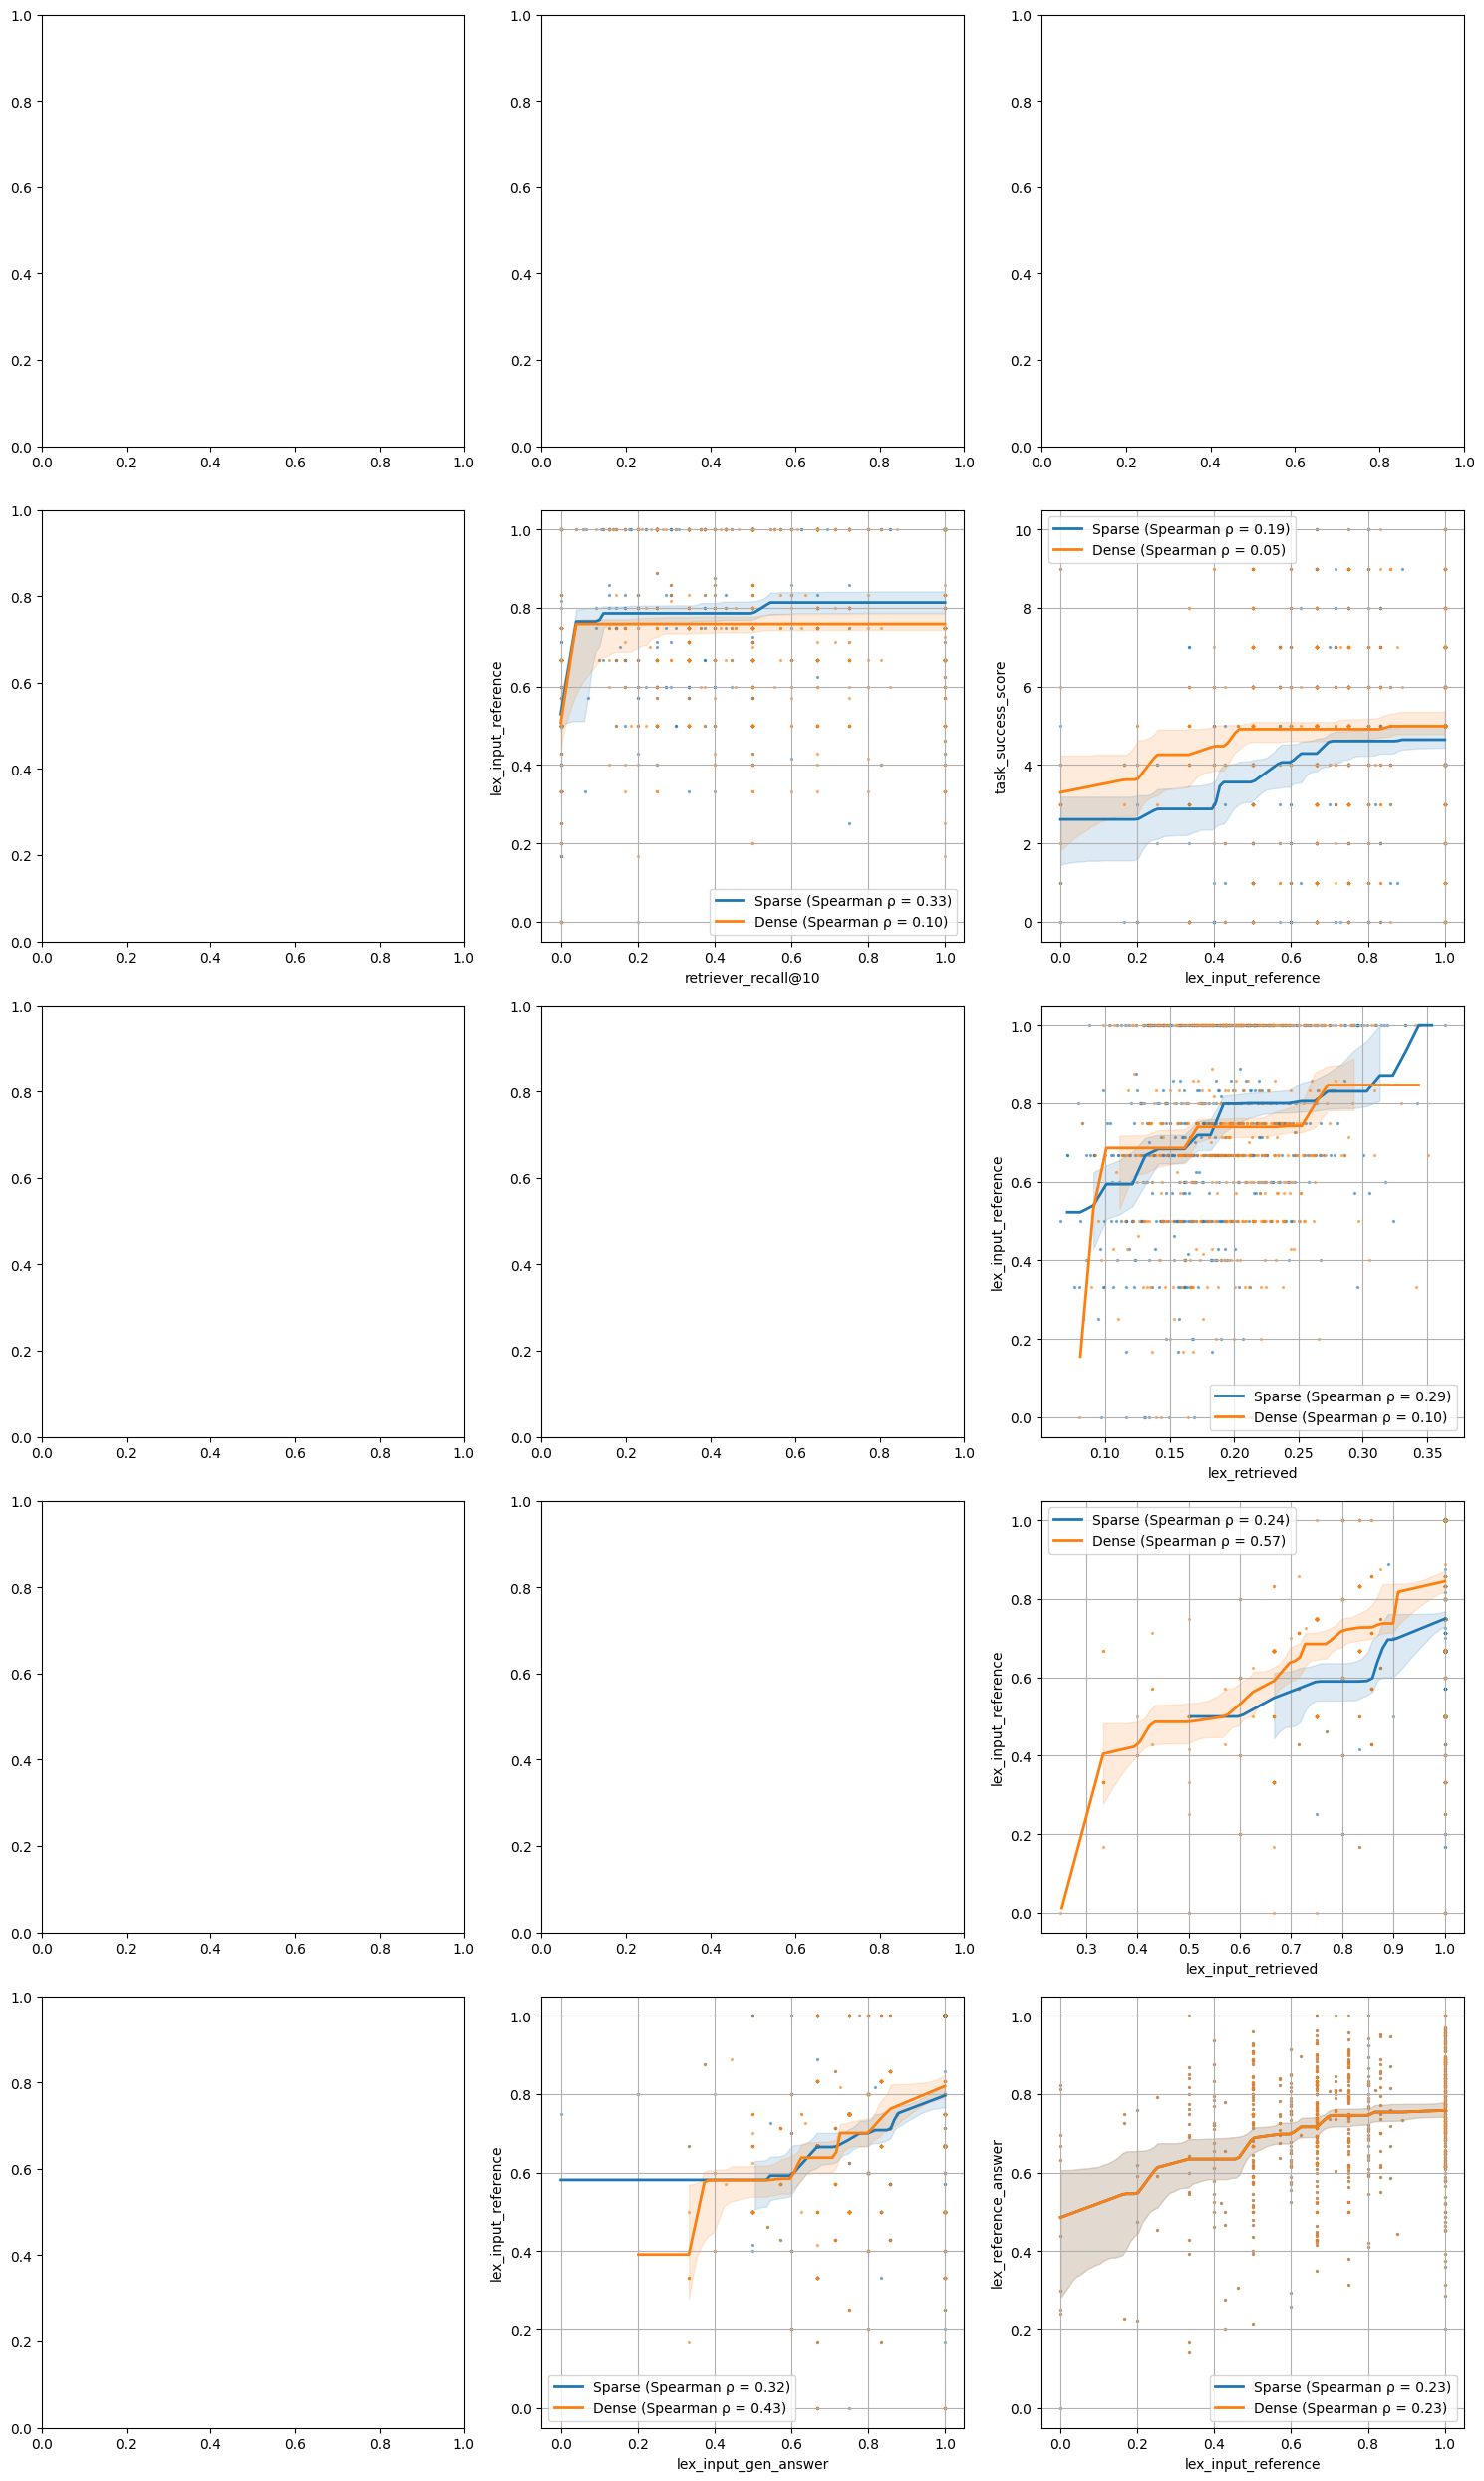

In [28]:
fig, axs = plt.subplots(5, 3, figsize=(15, 25))

def plot_relation(ax, a, b, x_min=0, x_max=1, y_min=0, y_max=1):
    for retriever in ['sparse', 'dense']:
        df = results[retriever]
        df = df.dropna(subset=[a, b], how='any')

        corr = df[a].corr(df[b], method='spearman')
        x_line = np.linspace(x_min, x_max, 100)
        iso_reg = IsotonicRegression(y_min=y_min, y_max=y_max).fit(df[a], df[b])
        ci_lower, ci_upper = bootstrap_isotonic_ci(df[a].values, df[b].values, x_line, y_min=y_min, y_max=y_max)
        y_line  = iso_reg.predict(x_line)

        p = ax.plot(x_line, y_line, linewidth=2, label=f"{retriever.capitalize()} (Spearman ρ = {corr:.2f})")
        color = p[-1].get_color()
        ax.fill_between(x_line, ci_lower, ci_upper, color=color, alpha=0.15)
        ax.scatter(df[a], df[b], color=color, s=2, alpha=0.5)

    ax.legend()
    ax.grid()
    ax.set_xlabel(a)
    ax.set_ylabel(b)

# plot_relation(axs[0][0], 'retriever_recall@10', 'lex_retrieved')
# plot_relation(axs[0][1], 'retriever_recall@10', 'lex_reference')
# plot_relation(axs[0][2], 'retriever_recall@10', 'task_success_score', y_max=10)

# plot_relation(axs[1][0], 'retriever_recall@10', 'lex_retrieved_answer')
plot_relation(axs[1][1], 'retriever_recall@10', 'lex_input_reference')
plot_relation(axs[1][2], 'lex_input_reference', 'task_success_score', y_max=10)
# plot_relation(axs[1][2], 'lex_retrieved', 'task_success_score', y_max=10)

# plot_relation(axs[2][0], 'lex_retrieved', 'lex_reference')
# plot_relation(axs[2][1], 'lex_retrieved', 'lex_retrieved_answer')
plot_relation(axs[2][2], 'lex_retrieved', 'lex_input_reference')

# plot_relation(axs[3][0], 'lex_reference', 'task_success_score', y_max=10)
# plot_relation(axs[3][1], 'lex_reference', 'lex_retrieved_answer')
plot_relation(axs[3][2], 'lex_input_retrieved', 'lex_input_reference')

# plot_relation(axs[4][0], 'lex_input_gen_answer', 'lex_input_retrieved')
plot_relation(axs[4][1], 'lex_input_gen_answer', 'lex_input_reference')
plot_relation(axs[4][2], 'lex_input_reference', 'lex_reference_answer')


plt.tight_layout()
plt.show()

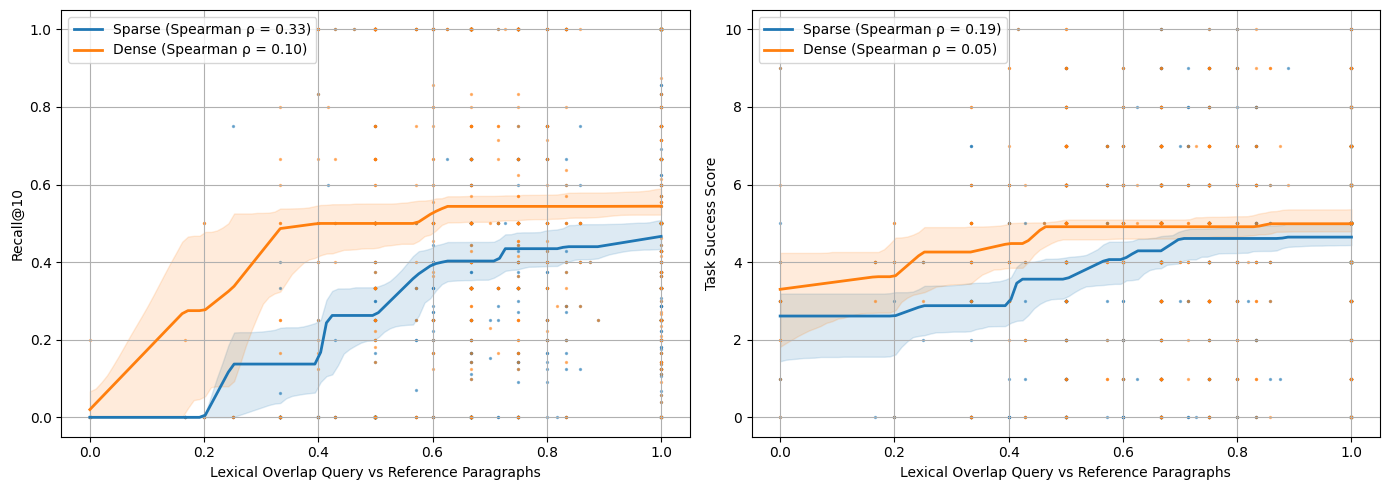

In [37]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

metrics = {
    'retriever_recall@10': 'Recall@10',
    'task_success_score': 'Task Success Score',
    'lex_input_reference': 'Lexical Overlap Query vs Reference Paragraphs'
}

def plot_relation(ax, a, b, x_min=0, x_max=1, y_min=0, y_max=1):
    for retriever in ['sparse', 'dense']:
        df = results[retriever]
        df = df.dropna(subset=[a, b], how='any')

        corr = df[a].corr(df[b], method='spearman')
        x_line = np.linspace(x_min, x_max, 100)
        iso_reg = IsotonicRegression(y_min=y_min, y_max=y_max).fit(df[a], df[b])
        ci_lower, ci_upper = bootstrap_isotonic_ci(df[a].values, df[b].values, x_line, y_min=y_min, y_max=y_max)
        y_line  = iso_reg.predict(x_line)

        p = ax.plot(x_line, y_line, linewidth=2, label=f"{retriever.capitalize()} (Spearman ρ = {corr:.2f})")
        color = p[-1].get_color()
        ax.fill_between(x_line, ci_lower, ci_upper, color=color, alpha=0.15)
        ax.scatter(df[a], df[b], color=color, s=2, alpha=0.5)

    ax.legend()
    ax.grid()
    ax.set_xlabel(metrics[a])
    ax.set_ylabel(metrics[b])

plot_relation(axs[0], 'lex_input_reference', 'retriever_recall@10')
plot_relation(axs[1], 'lex_input_reference', 'task_success_score', y_max=10)


plt.tight_layout()
plt.show()

In [20]:
df = results['sparse']

df = df.loc[df['retriever_recall@10'] == 1]
df[['lex_retrieved', 'lex_reference']].mean()

lex_retrieved    0.182176
lex_reference    0.368061
dtype: float64

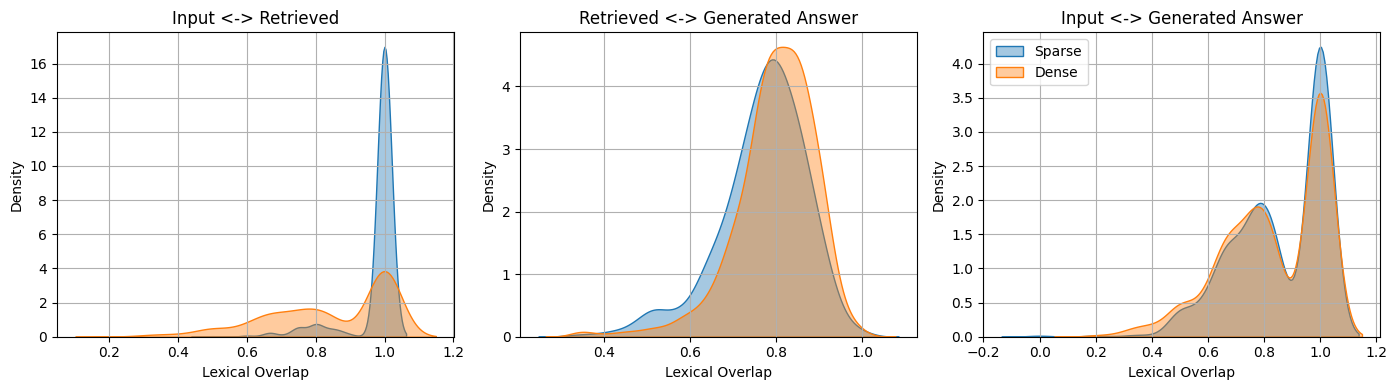

In [21]:
metrics = ["lex_input_retrieved", "lex_retrieved_answer", "lex_input_gen_answer"]
labels  = ["Input <-> Retrieved", "Retrieved <-> Generated Answer", "Input <-> Generated Answer"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes, metrics, labels):
    sns.kdeplot(results['sparse'][col], ax=ax, label="Sparse", fill=True, alpha=0.4)
    sns.kdeplot(results['dense'][col],  ax=ax, label="Dense",  fill=True, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel("Lexical Overlap")
    ax.grid()

    # ax.set_xlim(0, 1)

plt.legend()
plt.tight_layout()


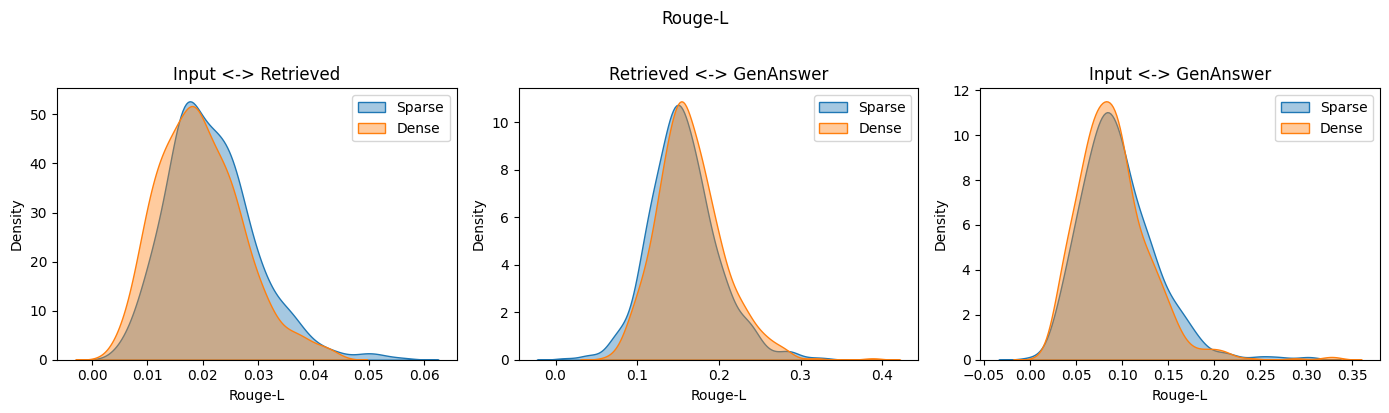

In [22]:


metrics = ["rouge_input_retrieved", "rouge_retrieved_answer", "rouge_input_gen_answer"]
labels  = ["Input <-> Retrieved", "Retrieved <-> GenAnswer", "Input <-> GenAnswer"]

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col, label in zip(axes, metrics, labels):
    sns.kdeplot(results['sparse'][col], ax=ax, label="Sparse", fill=True, alpha=0.4)
    sns.kdeplot(results['dense'][col],  ax=ax, label="Dense",  fill=True, alpha=0.4)
    ax.set_title(label)
    ax.set_xlabel("Rouge-L")
    ax.legend()

plt.suptitle("Rouge-L", y=1.02)
plt.tight_layout()


In [23]:
cols = [
    "lex_input_retrieved",
    "lex_retrieved_answer",
    "lex_input_gen_answer",
    "lex_input_reference",
    "lex_reference_answer"
]

summary = pd.DataFrame({
    "Sparse": results['sparse'][cols].mean(),
    "Dense":  results['dense'][cols].mean(),
})
summary["Delta (Sparse - Dense)"] = summary["Sparse"] - summary["Dense"]
print(summary.round(3))

                      Sparse  Dense  Delta (Sparse - Dense)
lex_input_retrieved    0.975  0.841                   0.134
lex_retrieved_answer   0.768  0.797                  -0.029
lex_input_gen_answer   0.855  0.831                   0.024
lex_input_reference    0.731  0.731                   0.000
lex_reference_answer   0.719  0.719                   0.000
